In [149]:
import importlib
import utils
importlib.reload(utils) 

<module 'utils' from 'E:\\KAGGLE\\s05e01_forecasting_sticker_sales\\utils.py'>

In [197]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [150]:
from utils import *

In [151]:
kaggle_cred_file = r'E:\env\KAGGLE_KEY\kaggle.json'
load_kaggle_creds(kaggle_cred_file)

In [152]:
competition = 'playground-series-s5e1'
download_competition_data(competition)

Data files already found


In [153]:
import pandas as pd

In [154]:
train_file = 'data/train.csv'

In [180]:
train_df = pd.read_csv(train_file)
train_df['date'] = pd.to_datetime(train_df['date'])


In [181]:
train_df.head()

,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


In [182]:
del train_df['id']

In [183]:
train_df.isna().sum()

date           0
country        0
store          0
product        0
num_sold    8871
dtype: int64

In [184]:
category_columns = ['date','country', 'store', 'product']

for col in category_columns:
    print(f'{col:<15} | {train_df[col].nunique()}')

date            | 2557
country         | 6
store           | 3
product         | 5


In [185]:
train_df[['country', 'store', 'product']].drop_duplicates().shape

(90, 3)

In [186]:
train_df.dtypes

date        datetime64[ns]
country             object
store               object
product             object
num_sold           float64
dtype: object

In [198]:
def create_date_features(df, date_col='date'):
    # Extract useful features
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['weekday'] = df['date'].dt.weekday  # Monday=0, Sunday=6
    df['weekday_name'] = df['date'].dt.day_name()
    df['quarter'] = df['date'].dt.quarter
    df['day_of_year'] = df['date'].dt.dayofyear
    df['week_of_year'] = df['date'].dt.isocalendar().week  # ISO week number
    df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)  # 1 if Sat/Sun, else 0
    df['days_in_month'] = df['date'].dt.days_in_month
    df['is_leap_year'] = df['date'].dt.is_leap_year.astype(int)  # 1 if leap year, else 0
    df['week_of_year'] = df['week_of_year'].astype('int32')
    return df

In [199]:
groupby_cols = ['country', 'store', 'product']
for index, data in train_df.groupby(groupby_cols):
    data = data.drop(columns  = groupby_cols)

In [200]:
data.shape

(2557, 2)

In [201]:
data.head()

,date,num_sold
84,2010-01-01,1080.0
174,2010-01-02,971.0
264,2010-01-03,987.0
354,2010-01-04,839.0
444,2010-01-05,795.0


In [202]:
def create_train_df(train_df):
    overall_data = train_df.copy()
    overall_data['num_sold'] = overall_data['num_sold'].fillna(round(overall_data['num_sold'].mean()))
    overall_data = overall_data.groupby('date')['num_sold'].sum().reset_index()
    overall_data = create_date_features(overall_data)
    return overall_data

In [203]:
data = create_train_df(data)
data = create_date_features(data)

In [204]:
data.head()

,date,num_sold,year,month,day,weekday,weekday_name,quarter,day_of_year,week_of_year,is_weekend,days_in_month,is_leap_year
0,2010-01-01,1080.0,2010,1,1,4,Friday,1,1,53,0,31,0
1,2010-01-02,971.0,2010,1,2,5,Saturday,1,2,53,1,31,0
2,2010-01-03,987.0,2010,1,3,6,Sunday,1,3,53,1,31,0
3,2010-01-04,839.0,2010,1,4,0,Monday,1,4,1,0,31,0
4,2010-01-05,795.0,2010,1,5,1,Tuesday,1,5,1,0,31,0


In [219]:
feature_set = [i for i in data.select_dtypes(include=[np.number]).columns if i not in ['date', 'num_sold']] 

In [220]:
feature_set = remove_high_vif_features(data[feature_set].copy(), threshold=5.0)

Dropping month with VIF: 222041.5079853301
Dropping days_in_month with VIF: 1650.7713278520944
Dropping day_of_year with VIF: 119.50996407936961
Dropping quarter with VIF: 53.550480673234816
Dropping year with VIF: 10.413393495453853
Dropping weekday with VIF: 6.446997587872107


In [236]:
def encode_cyclic_feature(df):
    # Encode cyclic features
    if 'day' in df.columns:
        df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
        df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)
        del df['day']
    if 'week_of_year' in df.columns: 
        df['week_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 53)
        df['week_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 53)
        del df['week_of_year']
    return df

In [237]:
feature_set = encode_cyclic_feature(feature_set)

In [238]:
X_train = feature_set.iloc[:-60]
X_test = feature_set.iloc[-60:]
y_train = data['num_sold'][:-60]
y_test = data['num_sold'][-60:]


In [239]:
X_train.tail()

,is_weekend,is_leap_year,day_sin,day_cos,week_sin,week_cos
2492,0,1,-5.712682e-01,0.820763,-0.926690,0.375828
2493,1,1,-3.943559e-01,0.918958,-0.926690,0.375828
2494,1,1,-2.012985e-01,0.979530,-0.926690,0.375828
2495,0,1,-2.449294e-16,1.000000,-0.875735,0.482792
2496,0,1,2.012985e-01,0.979530,-0.875735,0.482792


In [245]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X_train, y_train)

In [246]:
y_pred = reg.predict(X_test)

In [243]:
#X_test.describe()

In [247]:
from sklearn.metrics import mean_absolute_percentage_error

In [248]:
mean_absolute_percentage_error(y_test, y_pred)

0.07476217059470507

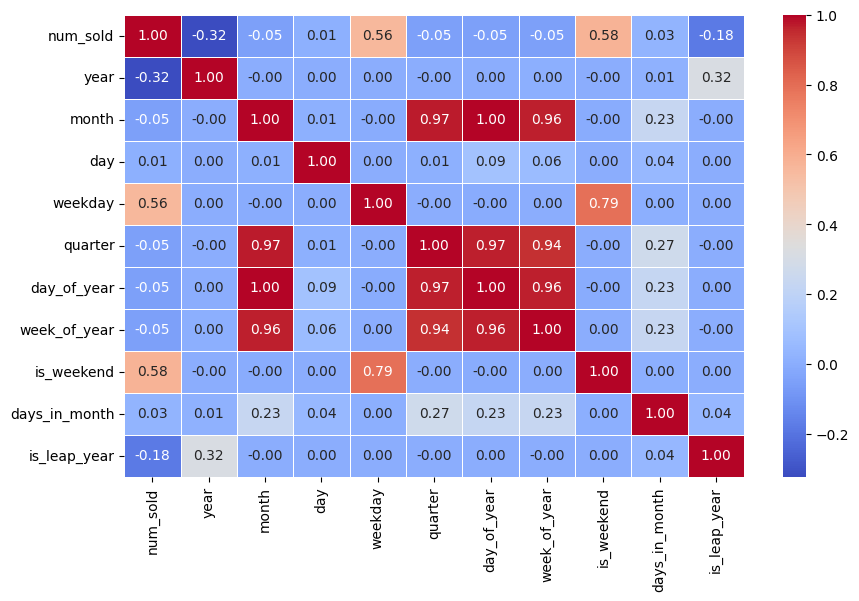

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_mat = overall_data.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.show()

In [101]:
#pip install statsmodels

In [103]:
overall_data.select_dtypes(include=['number']).columns

Index(['num_sold', 'year', 'month', 'day', 'weekday', 'quarter', 'day_of_year',
       'week_of_year', 'is_weekend', 'days_in_month', 'is_leap_year',
       'rolling_mean_7'],
      dtype='object')

In [126]:
num_cols = ['year', 'month', 'day', 'weekday', 'quarter', 'day_of_year',
       'week_of_year', 'is_weekend', 'days_in_month', 'is_leap_year']
X = overall_data[num_cols].copy()  # Select numerical time features

In [127]:
import numpy as np

In [128]:
X['week_of_year'] = X['week_of_year'].astype('int32')

In [129]:
[i for i in X1.columns if i not in X.columns]

[]

In [215]:
def remove_high_vif_features(X, threshold=5.0):
    """Removes features with VIF above the given threshold iteratively."""
    while True:
        # Calculate VIF for all features
        vif_data = pd.DataFrame()
        vif_data["Feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

        # Get the max VIF value and feature
        max_vif = vif_data["VIF"].max()
        if max_vif < threshold:
            break  # Stop if all VIFs are below threshold
        
        # Drop the feature with highest VIF
        feature_to_drop = vif_data.loc[vif_data["VIF"].idxmax(), "Feature"]
        print(f"Dropping {feature_to_drop} with VIF: {max_vif}")
        X = X.drop(columns=[feature_to_drop])

    return X

In [134]:
date_cols_to_use = remove_high_vif_features(X, threshold=5.0)

Dropping month with VIF: 222041.5079853301
Dropping days_in_month with VIF: 1650.7713278520944
Dropping day_of_year with VIF: 119.50996407936961
Dropping quarter with VIF: 53.550480673234816
Dropping year with VIF: 10.413393495453853
Dropping weekday with VIF: 6.446997587872107


In [135]:
date_cols_to_use.columns

Index(['day', 'week_of_year', 'is_weekend', 'is_leap_year'], dtype='object')

In [143]:
target_col = ['num_sold']
date_col = ['date']
cols_to_drop = [i for i in overall_data.columns if i not in [*date_cols_to_use.columns, *target_col, *date_col]]

In [146]:
cols_to_drop

['year',
 'month',
 'weekday',
 'weekday_name',
 'quarter',
 'day_of_year',
 'days_in_month',
 'rolling_mean_7']

In [147]:
overall_data = overall_data.drop(columns = cols_to_drop)

In [148]:
overall_data.head()

,date,num_sold,day,week_of_year,is_weekend,is_leap_year
0,2010-01-01,87072.0,1,53,0,0
1,2010-01-02,84054.0,2,53,1,0
2,2010-01-03,89834.0,3,53,1,0
3,2010-01-04,70334.0,4,1,0,0
4,2010-01-05,67972.0,5,1,0,0
